# EDA — Churn Prediction (Telco Customer Churn)

Exploración inicial del dataset descargado desde Kaggle (`blastchar/telco-customer-churn`).
Objetivo: entender la forma de los datos, la variable target (`Churn`), valores nulos, distribución de variables numéricas y categóricas, y relaciones preliminares con el churn.

## 1. Carga de datos

Descarga vía `kagglehub` (ver `src/download_data.py`) o lectura directa desde S3 si ya fue subido.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
# Opción A: descargar desde Kaggle con kagglehub
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [4]:
import glob, os

csv_path = glob.glob(os.path.join(path, "*.csv"))[0]
df = pd.read_csv(csv_path)
print(csv_path)
df.shape


/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


(7043, 21)

Alternativa: si el dataset ya fue subido a S3 (ver `src/s3_utils.py`), se puede leer directamente:
```python
import sys
sys.path.append("../src")
from s3_utils import read_csv_from_s3

df = read_csv_from_s3("raw/telco_churn.csv")
```

## 2. Primer vistazo

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Valores nulos y tipos

Nota conocida de este dataset: `TotalCharges` viene como tipo `object` porque algunas filas tienen strings vacíos (clientes con `tenure = 0`). Hay que convertirla a numérica y revisar cuántos casos hay.

In [8]:
df.isnull().sum().sort_values(ascending=False)


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
# TotalCharges como numérica; los strings vacíos se convierten en NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()


np.int64(11)

In [10]:
# Revisar esas filas: normalmente coinciden con tenure == 0
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


## 4. Variable target: `Churn`

Revisar el balance de clases — típicamente este dataset está desbalanceado (~73% No / ~27% Yes), lo cual es relevante para elegir métricas (AUC, F1) en vez de solo accuracy.

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


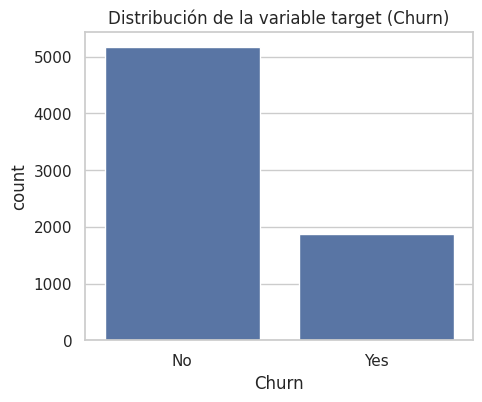

In [11]:
churn_counts = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn")
plt.title("Distribución de la variable target (Churn)")
plt.show()


## 5. Variables numéricas vs. Churn

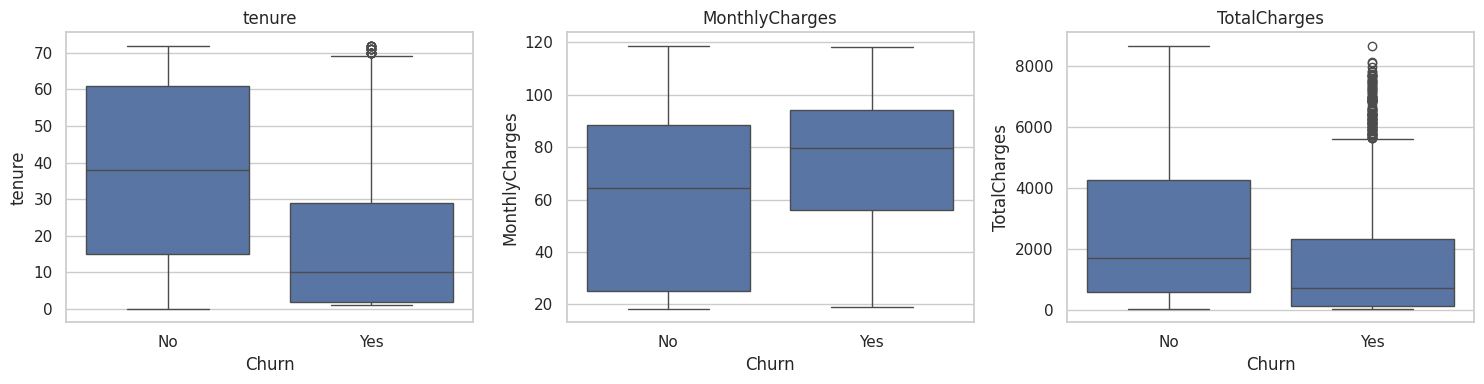

In [12]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


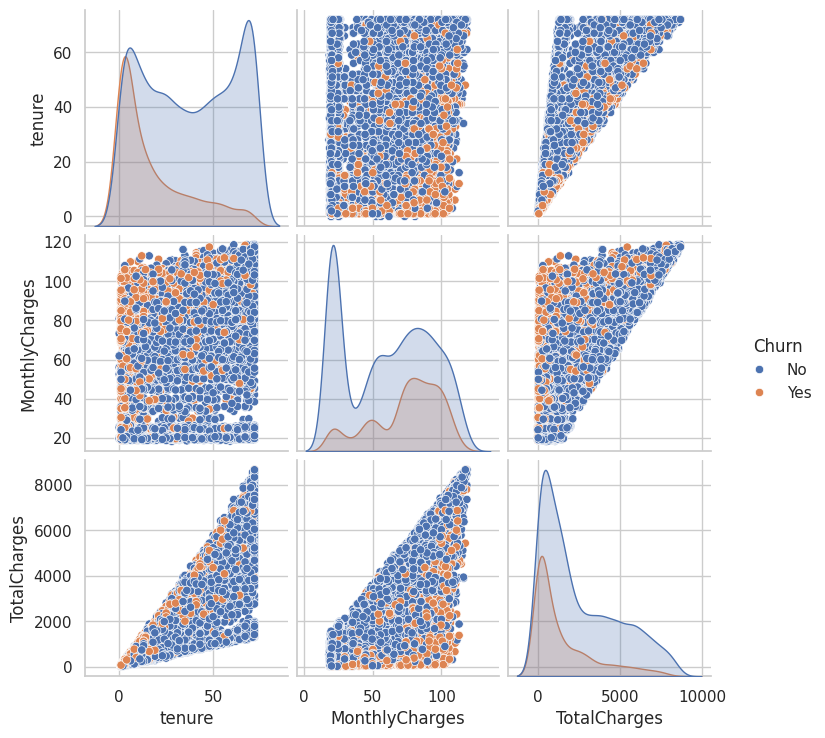

In [13]:
sns.pairplot(df[numeric_cols + ["Churn"]], hue="Churn", diag_kind="kde")
plt.show()


## 6. Variables categóricas vs. Churn

Revisar contrato, método de pago, tipo de internet, y servicios adicionales — suelen ser los predictores más fuertes en este dataset.

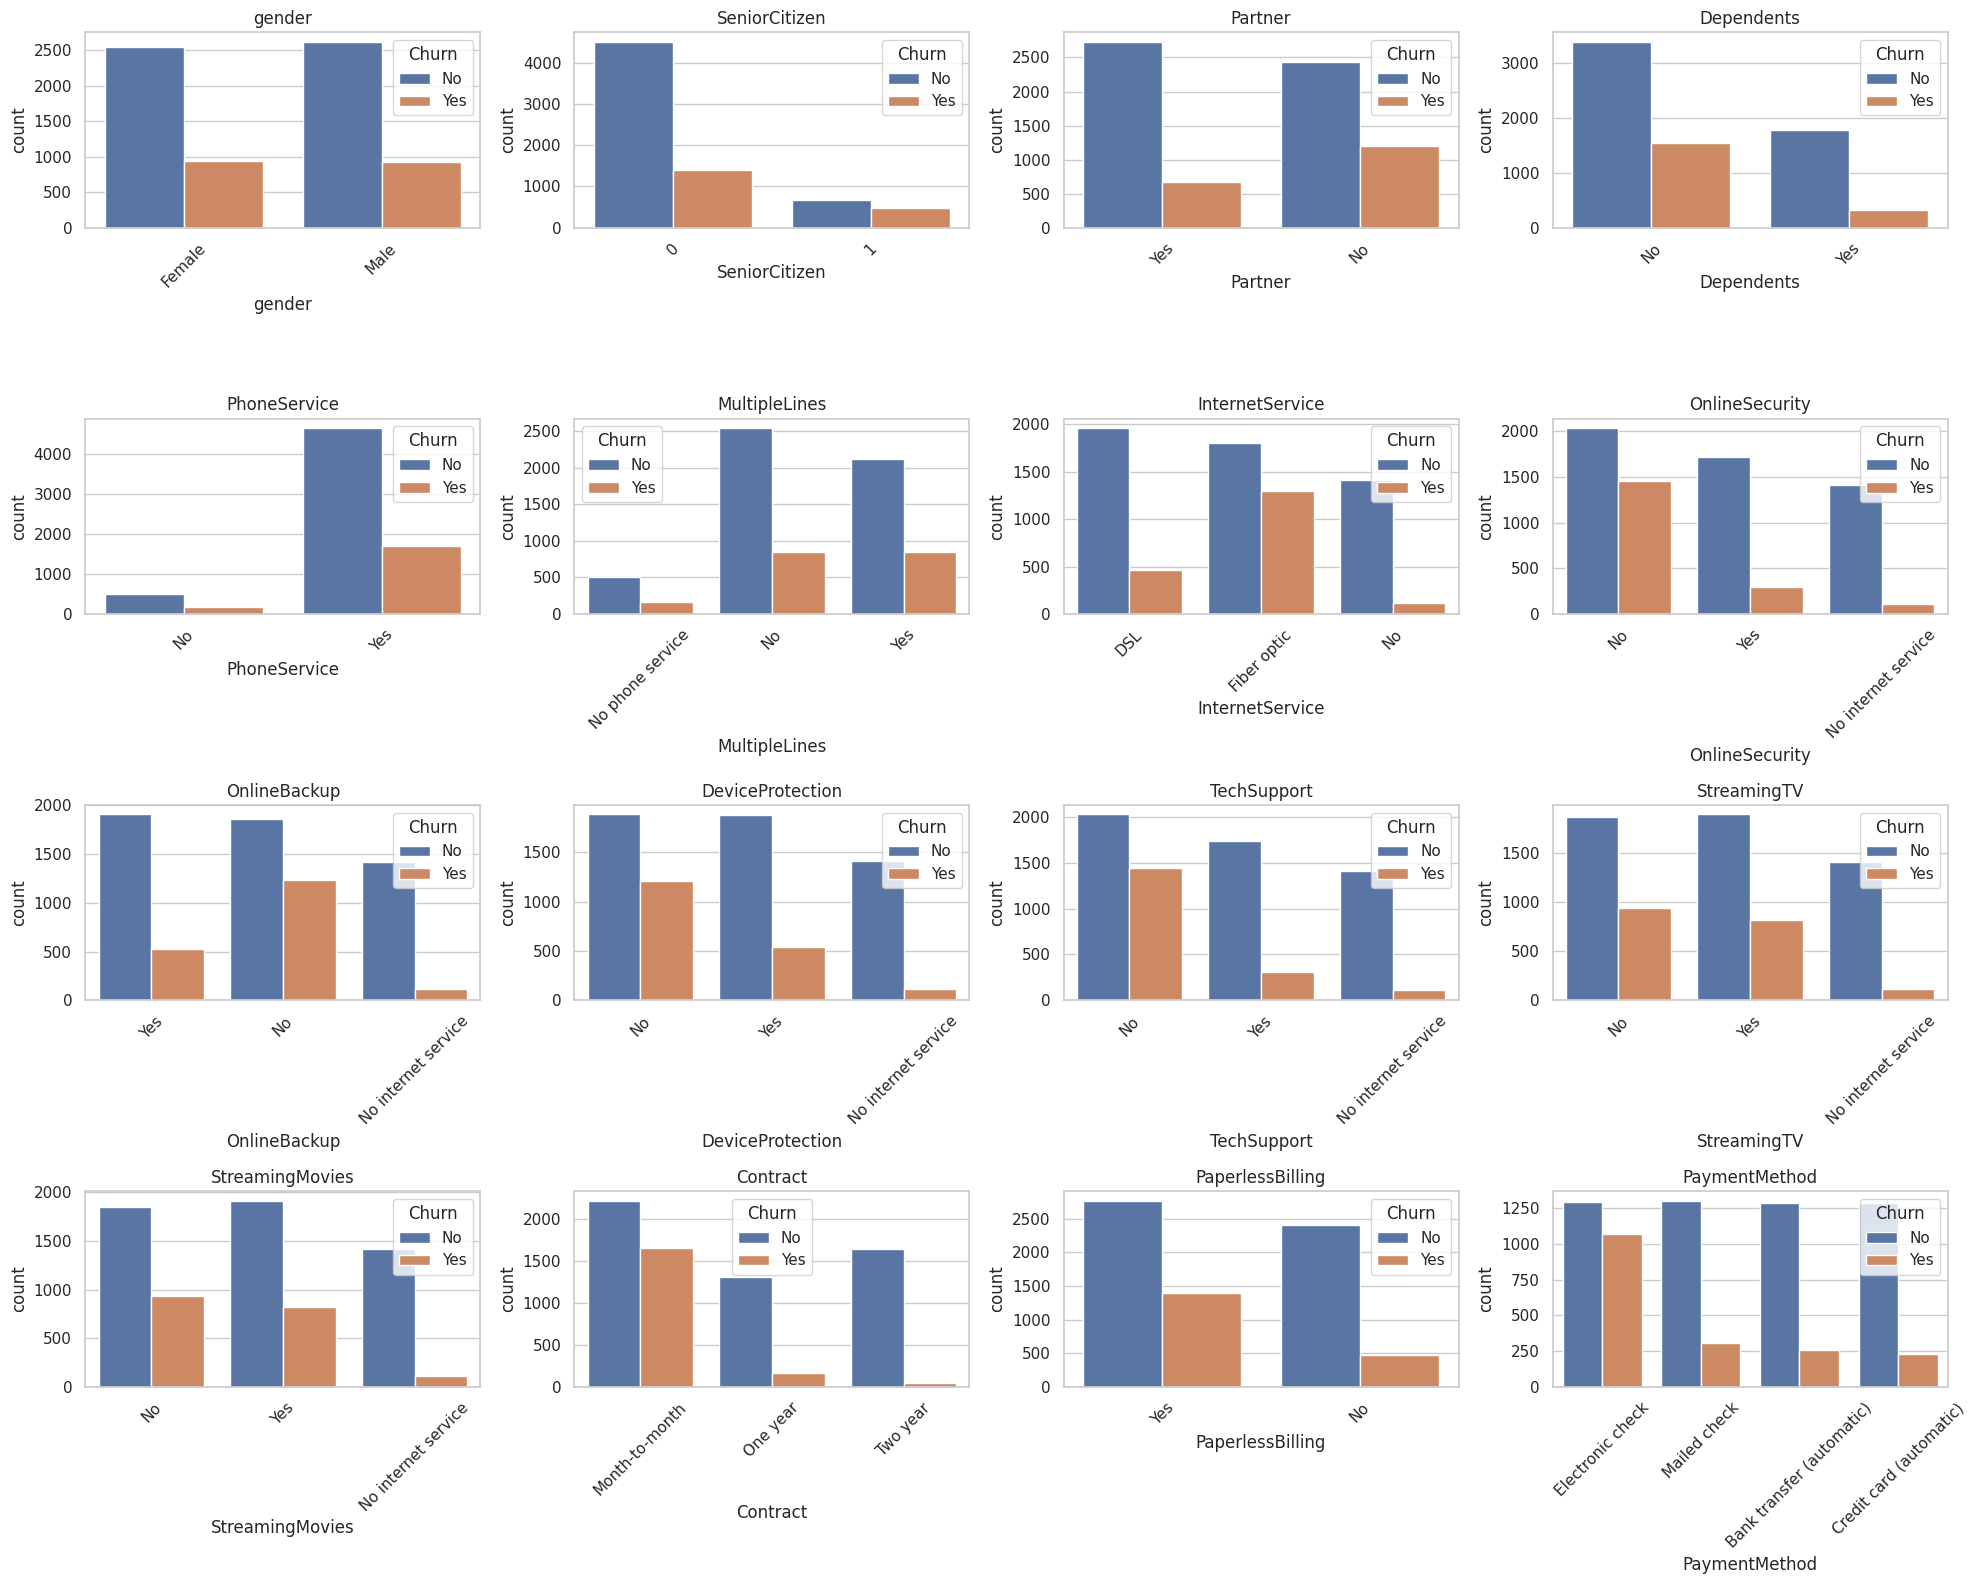

In [14]:
categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, hue="Churn", ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [15]:
# Churn rate por tipo de contrato (uno de los predictores más fuertes esperados)
contract_churn = df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)
contract_churn.sort_values(ascending=False)


,Churn
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


## 7. Correlaciones (variables numéricas)

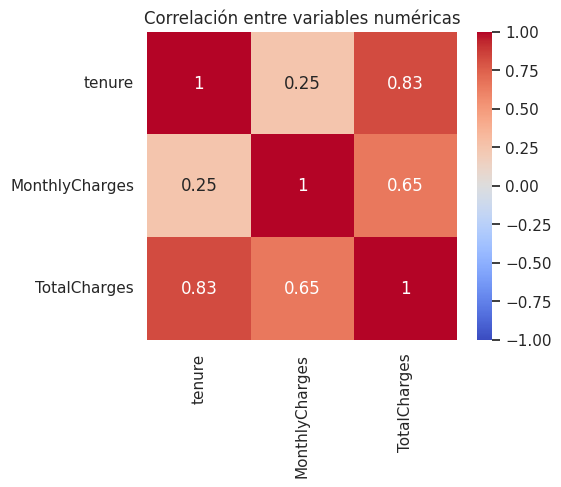

In [16]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre variables numéricas")
plt.show()


## 8. Notas y próximos pasos

- `TotalCharges` requiere conversión a numérico e imputación (o eliminación) de los ~11 casos nulos, todos con `tenure == 0`.
- `customerID` no aporta valor predictivo — se descarta antes de entrenar.
- Dataset desbalanceado → priorizar AUC y F1 sobre accuracy en la evaluación.
- `Contract`, `tenure` y `InternetService` aparecen como los predictores más fuertes a simple vista.
- Siguiente paso: `02_feature_engineering.ipynb` — encoding de categóricas, escalado de numéricas, y guardado del dataset limpio en S3 (`processed/telco_churn_clean.csv`).